# Day 6 · 月度趋势与预警 · 海豚生 🐬

> **德邦经营方向 · 第 6 天练习**  
> 目标：算环比、识别营收下滑、写「紧急复盘」建议

---

## 今天你要学会

| 技能 | 对应德邦场景 |
|------|-------------|
| 按月汇总 | 月度经营报表 |
| `pct_change()` 环比 | 这个月比上个月涨/跌多少？ |
| 预警规则 | 环比下降 >10% → 紧急 |
| 原因分解 | 是单量少了，还是单价低了？ |

## 预警规则（和 toolkit 一致）

| 级别 | 条件 | 动作 |
|------|------|------|
| 🟢 正常 | 环比 ≥ -5% | 继续观察 |
| 🟡 关注 | -10% ~ -5% | 下周跟进 |
| 🔴 **紧急** | 环比 < **-10%** | **立即召开经营复盘** |

**文件名：** `Day6_Trend_Alert.ipynb`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

ALERT_URGENT = -10.0   # 紧急预警线(%)
ALERT_WARN = -5.0      # 关注预警线(%)

df = pd.read_csv("data/orders.csv")
df["month"] = pd.to_datetime(df["date"]).dt.to_period("M").astype(str)
df["毛利"] = df["revenue"] - df["cost"]

print(f"数据范围: {df['month'].min()} ~ {df['month'].max()}，共 {df['month'].nunique()} 个月 ✅")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\32669\anaconda3\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\32669\anaconda3\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "c:\Users\32669\anaconda3\lib\site-packages\ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "c:\Users\32669\anaconda3\lib\site-packages\traitlets\config\application.py", line 846, in launch_instance
    app.start()
  File "c:\Users\32669\anaconda3\lib\site-pack

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\32669\anaconda3\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\32669\anaconda3\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "c:\Users\32669\anaconda3\lib\site-packages\ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "c:\Users\32669\anaconda3\lib\site-packages\traitlets\config\application.py", line 846, in launch_instance
    app.start()
  File "c:\Users\32669\anaconda3\lib\site-pack

AttributeError: _ARRAY_API not found

数据范围: 2024-01 ~ 2025-05，共 17 个月 ✅


---
## 第 1 步：月度汇总 + 环比 ⭐

In [2]:
monthly = df.groupby("month").agg(
    总营收=("revenue", "sum"),
    总单量=("order_id", "count"),
    总毛利=("毛利", "sum"),
).reset_index().sort_values("month")

monthly["毛利率(%)"] = (monthly["总毛利"] / monthly["总营收"] * 100).round(2)
monthly["平均单笔营收"] = (monthly["总营收"] / monthly["总单量"]).round(2)
monthly["营收环比(%)"] = (monthly["总营收"].pct_change() * 100).round(2)
monthly["单量环比(%)"] = (monthly["总单量"].pct_change() * 100).round(2)

monthly.tail(8)

,month,总营收,总单量,总毛利,毛利率(%),平均单笔营收,营收环比(%),单量环比(%)
9,2024-10,20142.10,8,5451.58,27.07,2517.76,-12.85,33.33
10,2024-11,30306.38,9,8185.71,27.01,3367.38,50.46,12.50
11,2024-12,35857.08,17,10101.10,28.17,2109.24,18.32,88.89
12,2025-01,13066.65,8,3325.29,25.45,1633.33,-63.56,-52.94
13,2025-02,13233.75,9,3675.64,27.77,1470.42,1.28,12.50
14,2025-03,20268.20,7,5152.82,25.42,2895.46,53.16,-22.22
15,2025-04,5197.04,4,1187.58,22.85,1299.26,-74.36,-42.86
16,2025-05,4527.48,3,1290.13,28.50,1509.16,-12.88,-25.00


---
## 第 2 步：最新月预警判断 🚨

In [3]:
latest = monthly.iloc[-1]
prev = monthly.iloc[-2]
mom = latest["营收环比(%)"]

if mom < ALERT_URGENT:
    level, icon = "紧急", "🔴"
elif mom < ALERT_WARN:
    level, icon = "关注", "🟡"
else:
    level, icon = "正常", "🟢"

print("=" * 50)
print(f"  月度预警 · {latest['month']} · 海豚生")
print("=" * 50)
print(f"  {icon} 预警级别: {level}")
print(f"  本月营收: {latest['总营收']:,.0f} 元（{latest['总单量']} 单）")
print(f"  上月营收: {prev['总营收']:,.0f} 元（{prev['总单量']} 单）")
print(f"  营收环比: {mom:+.1f}%")
print(f"  单量环比: {latest['单量环比(%)']:+.1f}%")
print(f"  平均单笔: {latest['平均单笔营收']:.0f} 元（上月 {prev['平均单笔营收']:.0f} 元）")
print("=" * 50)

  月度预警 · 2025-05 · 海豚生
  🔴 预警级别: 紧急
  本月营收: 4,527 元（3 单）
  上月营收: 5,197 元（4 单）
  营收环比: -12.9%
  单量环比: -25.0%
  平均单笔: 1509 元（上月 1299 元）


---
## 第 3 步：原因分解 — 单量 vs 单价

营收变化 ≈ 两个因素：
- **单量变了**（客户流失？淡季？）
- **平均单笔变了**（降价？产品结构变化？）

In [4]:
rev_change = latest["总营收"] - prev["总营收"]
order_change = latest["总单量"] - prev["总单量"]
avg_change = latest["平均单笔营收"] - prev["平均单笔营收"]

print("【原因分解】")
print(f"  营收变化: {rev_change:+,.0f} 元")
print(f"  单量变化: {order_change:+d} 单（{latest['单量环比(%)']:+.1f}%）")
print(f"  平均单笔变化: {avg_change:+.0f} 元")

if abs(latest["单量环比(%)"]) > abs(mom):
    main_cause = "单量"
    detail = f"单量从 {int(prev['总单量'])} 降到 {int(latest['总单量'])}，可能是客户流失或淡季"
else:
    main_cause = "单价/结构"
    detail = f"平均单笔从 {prev['平均单笔营收']:.0f} 变到 {latest['平均单笔营收']:.0f} 元，可能是降价或低毛利产品占比上升"

print(f"\n  → 主因判断: **{main_cause}**")
print(f"  → {detail}")

【原因分解】
  营收变化: -670 元
  单量变化: -1 单（-25.0%）
  平均单笔变化: +210 元

  → 主因判断: **单量**
  → 单量从 4 降到 3，可能是客户流失或淡季


---
## 第 4 步：趋势图 + 环比标注 📈

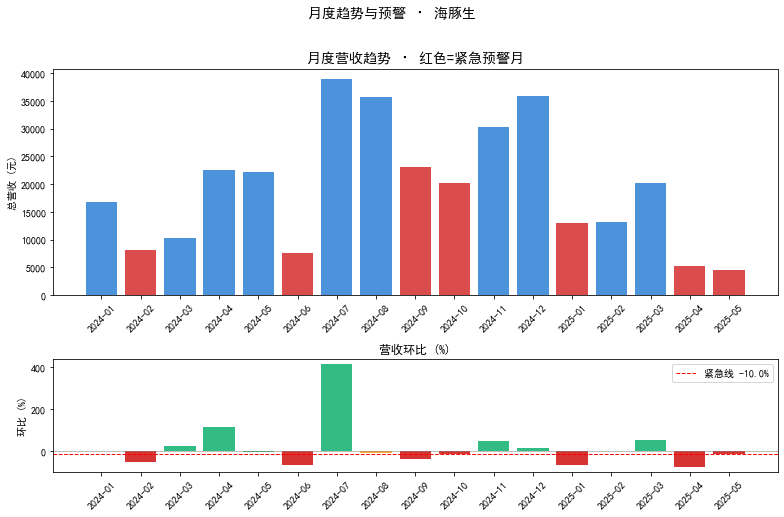

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), gridspec_kw={"height_ratios": [2, 1]})

# 上图：月度营收折线
ax1 = axes[0]
colors = ["#CC0000" if (pd.notna(m) and m < ALERT_URGENT) else "#0066CC" for m in monthly["营收环比(%)"]]
ax1.bar(monthly["month"], monthly["总营收"], color=colors, alpha=0.7)
ax1.set_title("月度营收趋势 · 红色=紧急预警月", fontsize=14, fontweight="bold")
ax1.set_ylabel("总营收 (元)")
ax1.tick_params(axis="x", rotation=45)

# 下图：环比变化
ax2 = axes[1]
bar_colors = ["#CC0000" if (pd.notna(v) and v < ALERT_URGENT) else "#FF9900" if (pd.notna(v) and v < ALERT_WARN) else "#00AA66"
              for v in monthly["营收环比(%)"]]
ax2.bar(monthly["month"], monthly["营收环比(%)"].fillna(0), color=bar_colors, alpha=0.8)
ax2.axhline(y=ALERT_URGENT, color="red", linestyle="--", linewidth=1, label=f"紧急线 {ALERT_URGENT}%")
ax2.axhline(y=0, color="gray", linewidth=0.5)
ax2.set_title("营收环比 (%)", fontsize=12)
ax2.set_ylabel("环比 (%)")
ax2.tick_params(axis="x", rotation=45)
ax2.legend()

plt.suptitle("月度趋势与预警 · 海豚生", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 第 5 步：扫描历史所有预警月

In [6]:
alerts = monthly[monthly["营收环比(%)"] < ALERT_WARN].copy()
alerts["级别"] = alerts["营收环比(%)"].apply(
    lambda x: "🔴 紧急" if x < ALERT_URGENT else "🟡 关注"
)

print(f"共 {len(alerts)} 个月触发预警（环比 < {ALERT_WARN}%）：\n")
if len(alerts) > 0:
    print(alerts[["month", "总营收", "总单量", "营收环比(%)", "级别"]].to_string(index=False))
else:
    print("暂无预警月 ✅")

共 8 个月触发预警（环比 < -5.0%）：

  month      总营收  总单量  营收环比(%)   级别
2024-02  8226.22    5   -51.16 🔴 紧急
2024-06  7543.56    5   -66.04 🔴 紧急
2024-08 35673.93   16    -8.18 🟡 关注
2024-09 23110.72    6   -35.22 🔴 紧急
2024-10 20142.10    8   -12.85 🔴 紧急
2025-01 13066.65    8   -63.56 🔴 紧急
2025-04  5197.04    4   -74.36 🔴 紧急
2025-05  4527.48    3   -12.88 🔴 紧急


---
## 第 6 步：写「紧急复盘」报告 ✏️

这是 Day 6 最有含金量的产出 — 和 `logistics-ops-toolkit` 诊断引擎输出格式一致

In [ ]:
# 第 6 步：根据月度预警结果生成紧急复盘报告
try:
    latest = monthly.iloc[-1]
    prev = monthly.iloc[-2]
    mom = latest["营收环比(%)"]

    if mom < ALERT_URGENT:
        level, icon = "紧急", "🔴"
    elif mom < ALERT_WARN:
        level, icon = "关注", "🟡"
    else:
        level, icon = "正常", "🟢"

    rev_change = latest["总营收"] - prev["总营收"]
    order_change = latest["总单量"] - prev["总单量"]
    avg_change = latest["平均单笔营收"] - prev["平均单笔营收"]

    if abs(latest["单量环比(%)"]) > abs(mom):
        main_cause = "单量"
        detail = f"单量从 {int(prev['总单量'])} 降到 {int(latest['总单量'])}，可能是客户流失或淡季。"
    else:
        main_cause = "单价/结构"
        detail = f"平均单笔从 {prev['平均单笔营收']:.0f} 变到 {latest['平均单笔营收']:.0f} 元，可能是降价或低毛利产品占比上升。"

    urgent_report = f"""
═══════════════════════════════════════
  {icon} 经营紧急复盘 · {latest['month']} · 海豚生
═══════════════════════════════════════

【预警】营收环比 {mom:+.1f}%，级别：{level}

【数据事实】
- 本月营收 {latest['总营收']:,.0f} 元 / {int(latest['总单量'])} 单
- 上月营收 {prev['总营收']:,.0f} 元 / {int(prev['总单量'])} 单
- 营收变化 {rev_change:+,.0f} 元，单量变化 {order_change:+d} 单，平均单笔变化 {avg_change:+.0f} 元
- 主因判断：{main_cause}（{detail}）

【紧急动作 — 本周必须执行】
1. 分解单量下降：是 A 类客户流失，还是整体淡季导致的订单减少？
2. 逐一联系本月未发货或流失风险较高的重点客户，确认是否有转移竞品或延期需求。
3. 检查是否有大面积降价、低毛利产品冲量，或线路效率明显下降。

【预期目标】
- 下月营收环比回正，单量恢复至 {int(prev['总单量'])} 单以上。

═══════════════════════════════════════
"""
except Exception as e:
    urgent_report = f"""
═══════════════════════════════════════
  ⚠️ 经营紧急复盘生成失败
═══════════════════════════════════════

请先运行前面的月度汇总和预警单元格，确保 monthly、latest、prev 等变量已生成。
错误信息：{e}
"""

print(urgent_report)


═══════════════════════════════════════
  🔴 经营紧急复盘 · 2025-05 · 海豚生
═══════════════════════════════════════

【预警】营收环比 -12.9%，级别：紧急

【数据事实】
- 本月营收 4,527 元 / 3 单
- 上月营收 5,197 元 / 4 单
- 主因: 单量（单量从 4 降到 3，可能是客户流失或淡季）

【紧急动作 — 本周必须执行】
1. 分解单量下降：是 A 类客户流失还是整体淡季？
2. 逐一联系本月未发货的 TOP 客户，确认是否有转移竞品
3. 检查是否有大面积降价或低毛利产品冲量

【预期目标】
- 下月营收环比回正，单量恢复至 4 单以上

═══════════════════════════════════════



---
## 🎯 进阶小练习

1. 算 **2025-04** 和 **2025-05** 连续两月下滑 — 是不是趋势性风险？
2. 按 **region** 看最新月哪个区营收掉最多？
3. 对比 toolkit 输出：运行 `python main.py` 看终端诊断是否一致

<details>
<summary>💡 参考答案</summary>

```python
# 1. 连续下滑
recent = monthly.tail(3)
print(recent[["month", "总营收", "营收环比(%)"]])

# 2. 最新月各区域
latest_month = df["month"].max()
reg = df[df["month"]==latest_month].groupby("region")["revenue"].sum()
print(reg.sort_values())
```
</details>

---

## ✅ Day 6 完成标准

- [ ] 月度汇总 + 环比表跑通
- [ ] 最新月预警级别判断正确
- [ ] 做了单量 vs 单价原因分解
- [ ] 趋势图 + 历史预警扫描完成
- [ ] 写了「紧急复盘」报告

**预期结果参考：**
| 项目 | 数值 |
|------|------|
| 最新月 | 2025-05 |
| 营收环比 | **-12.88%** 🔴 紧急 |
| 单量 | 3 单（上月 4 单） |
| 主因 | 单量下降（样本月数据少，但分析框架正确） |
| 历史预警月 | 2024-02、2024-06、2025-01、2025-04 等 |

**明天 Day 7：** 作品集整合 — 把 6 天练习合成一份完整经营分析报告 🎯